In [5]:
import os
import tensorflow as tf
import numpy as np
import math
from random import sample,shuffle
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,Reshape,Conv2DTranspose,BatchNormalization,Conv1D,Input,Layer
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import keras

In [6]:
!pip install librosa

Data Generator

In [7]:
import numpy as np
from random import sample,shuffle
import os
import tensorflow as tf
import numpy.ma as ma
import requests
import librosa
from skimage.transform import resize
from tqdm import tqdm

In [8]:
class AudioDataGenerator(tf.keras.utils.Sequence):
    def __init__(self,directory,
                image_size,color_mode='grayscale',
                batch_size=32,shuffle=False,
                sample_size=None,train_test_split=False,
                test_size=.2,
                file_list=None,
                name="Generator",
                output_channel_index=None,num_output_channels=1,output_size=None,
                threshold_level=0,):
        self.dir=directory
        self._image_size=image_size
        self._img_height=image_size[0]
        self._img_width=image_size[1]
        self._color_mode=color_mode
        if color_mode=='grayscale':
            self._img_channels=1
        elif color_mode=='rgb':
            self._img_channels=3
        self.output_channel_index=output_channel_index
        self.num_output_channels=num_output_channels
        self.output_size=output_size
        self.shuffle=shuffle
        self.sample_size=sample_size
        self.test_size=test_size
        self.batch_size=batch_size
        self.threshold_level=threshold_level
        if file_list==None:
            self._files=self.__get_images_from_directory(directory)
        else:
            try:
                self._files=self.__collect_image_files(file_list)
            except TypeError:
                print('file_list is not a list')
        if train_test_split:
            self.__train_test_split(self._files)
        else:
            print(f'Found {len(self._files)} files for {name} set')
        self.size=len(self._files)
        self.on_epoch_end()
    def __len__(self):
      return len(self._files)//self.batch_size
    def __getitem__(self,index=0,return_filename=False,get_all_tiles=False,num_tiles=4,image=False,image_data=None,filename=None):
        if filename==None:
            batch=self._files[index*self.batch_size:index*self.batch_size+self.batch_size]
        else:
            batch=[filename]
        X,y=self.__get_data(batch,image,image_data)
        if self.output_channel_index !=None:
            X=X[:,:,:,self.output_channel_index:self.output_channel_index+self.num_output_channels]
            y=y[:,:,:,self.output_channel_index:self.output_channel_index+self.num_output_channels]
        if self.output_size !=None:
            if get_all_tiles==False:
                if self.output_size[1]<self._img_width:
                    rand_x_index=np.random.randint(low=0,high=self._img_width-self.output_size[1])
                else:
                    rand_x_index=0
                if self.output_size[0]<self._img_height:
                    rand_y_index=np.random.randint(low=0,high=self._img_height-self.output_size[0])
                else:
                    rand_y_index=0
                X=X[:,rand_y_index:rand_y_index+self.output_size[0],rand_x_index:rand_x_index+self.output_size[1],:]
                y=X
            else:
                if num_tiles >1:
                    slice_size=(self._img_width-self.output_size[1])//(num_tiles-1)
                else:
                    slice_size=0
                all_tiles=[]
                new_batch=[]
                for idx,img in enumerate(X):
                    for i in range(num_tiles):
                        all_tiles.append(img[:,i*slice_size:(i*slice_size)+self.output_size[1],:])
                        new_batch.append(batch[idx])
                X=np.array(all_tiles)
                y=X
                if return_filename:
                    batch=new_batch
        if return_filename:
            return batch,X,y
        else:
            return X,y
    def on_epoch_end(self):
        if self.shuffle:
            shuffle(self._files)
    def __get_data(self,batch,image=False,image_data=None):
        X=np.empty((self.batch_size,self._img_height,self._img_width,self._img_channels))
        for i,file in enumerate(batch):
            if image==False:
                path=self.dir+file
                img=tf.keras.preprocessing.image.load_img(path,color_mode=self._color_mode)
            else:
                img=image_data
            scale=1./255
            img=scale*np.array(img)
            if self.threshold_level>0:
                img_min=img.min()
                img_max=img.max()
                threshold=self.threshold_level*(img_max-img_min)+img_min
                mx=ma.masked_where(img<threshold,img,copy=True)
                img=(mx.filled(fill_value=threshold)-threshold)
                img=img*(img_max/img.max())
            X[i,]=tf.convert_to_tensor(img)
        y=X
        return X,y
    def take(self,index=1,return_filename=False,get_all_tiles=False,num_tiles=4):
        return self.__getitem__(index,return_filename,get_all_tiles,num_tiles)
    def __train_test_split(self,files):
        if self.shuffle:
            shuffle(files)
        file_list_length=len(files)
        print(f"Total {len(files)} images")
        test_split=int(file_list_length*(1-self.test_size))
        train_files=files[:test_split]
        test_files=files[test_split:]
        self.train=AudioDataGenerator(self.dir,self._image_size,batch_size=self.batch_size,color_mode=self._color_mode,shuffle=self.shuffle,file_list=train_files,name='Train',output_channel_index=self.output_channel_index,output_size=self.output_size)
        self.test = AudioDataGenerator(self.dir, self._image_size, batch_size=self.batch_size, color_mode=self._color_mode, shuffle=self.shuffle, file_list=test_files, name='Test', output_channel_index=self.output_channel_index, output_size=self.output_size)
    def __collect_image_files(self,files):
        filetypes=['png','jpg','jpeg','webp']
        return [file for file in files if file.split('.')[-1] in filetypes]
    def __get_images_from_directory(self,directory):
        files=[]
        for folder in os.listdir(directory):
            files+=[os.path.join(folder,'comp_pngs',name) for name in os.listdir(os.path.join(directory,folder,'comp_pngs'))]
        files=self.__collect_image_files(files)
        if self.shuffle:
            shuffle(files)
        if self.sample_size !=None:
            files=sample(files,self.sample_size)
        return files


helper_functions

In [10]:
def progress_bar(progress,total,display_length=60):
    left_ratio=display_length*progress//total
    right_ratio=display_length-left_ratio
    print('['+ '='*left_ratio + '>' + '.'*right_ratio + f'] {progress} / {total}', end='\r') 
def plot_reconstruction(image,prediction,num_channels):
    fig,ax=plt.subplots(ncols=3,figsize=(10,3))
    ax[0].title.set_text('Original image')
    ax[0].imshow(image[0])
    ax[1].title.set_text('Reconstructed image')
    ax[1].imshow(prediction[0])
    ax[2].title.set_text('Difference')
    ax[2].imshow(prediction[0]-image[0],cmap='Spectral')
    plt.tight_layout()
    plt.show()
    if num_channels==3:
        fix,ax=plt.subplots(nrows=3,ncols=2,figsize=(10,5))
        ax[0][0].title.set_text('Original Mel Spectogram')
        ax[0][0].imshow(np.array(image[0][:,:,0]), cmap='Reds')
        ax[1][0].title.set_text('Original MFCC')
        ax[1][0].imshow(np.array(image[0][:,:,1]), cmap='Greens')
        ax[2][0].title.set_text('Original Chromagram')
        ax[2][0].imshow(np.array(image[0][:,:,2]), cmap='Blues')
        ax[0][1].title.set_text('Reconstructed Mel Spectogram')
        ax[0][1].imshow(np.array(prediction[0][:,:,0]), cmap='Reds')
        ax[1][1].title.set_text('Reconstructed MFCC')
        ax[1][1].imshow(np.array(prediction[0][:,:,1]), cmap='Greens')
        ax[2][1].title.set_text('Reconstructed Chromagram')
        ax[2][1].imshow(np.array(prediction[0][:,:,2]), cmap='Blues')
        plt.tight_layout()
        plt.show()

In [11]:
data_gen=AudioDataGenerator(
    directory='/kaggle/input/datasets/hau100416/music-mel-spectrogram-dataset/',
    image_size=(128,512),
    color_mode='rgb',
    batch_size=32,
    sample_size=200000,
    shuffle=True,
    train_test_split=True,
    test_size=0.02,
    output_channel_index=0,
    output_size=((128,128))
)

Total 200000 images
Found 196000 files for Train set
Found 4000 files for Test set


In [17]:
img_width=128
img_height=128
kernel_size=5
strides=2

In [19]:
class Time_Freq_Autoencoder_Builder:
    def build(width,height,depth,filters=(32,64,128,256),latent_dim=256,kernel_size=5):
        strides=2
        input_shape=(height,width,depth)
        inputs=Input(shape=input_shape)
        chan_dim=-1
        x_time=Reshape(target_shape=(height,width))(inputs)
        x_freq=Reshape(target_shape=(height,width))(keras.ops.transpose(inputs,axes=[0,1,2,3]))
        for f in filters:
            x_time=Conv1D(f,kernel_size=kernel_size,strides=strides,padding='same',activation='relu')(x_time)
            x_time=BatchNormalization(axis=chan_dim)(x_time)
        x_time=Flatten()(x_time)
        latent_time=Dense(latent_dim//2)(x_time)
        for f in filters:
            x_freq=Conv1D(f,kernel_size=kernel_size,strides=strides,padding='same',activation='relu')(x_freq)
            x_freq=BatchNormalization(axis=chan_dim)(x_freq)
        x_freq=Flatten()(x_freq)
        latent_freq=Dense(latent_dim//2)(x_freq)
        latent_concat=tf.keras.layers.Concatenate(axis=1)([latent_time,latent_freq])
        encoder=Model(inputs,latent_concat,name='encoder')
        latent_inputs=Input(shape=((latent_dim//2)*2,))
        x=Dense(16384,activation='relu')(latent_inputs)
        x=Reshape(target_shape=(8,8,256))(x)
        for f in filters[::-1]:
            x=Conv2DTranspose(f,kernel_size=kernel_size,strides=strides,padding='same',activation='relu')(x)
            x=BatchNormalization(axis=chan_dim)(x)
        x=Conv2DTranspose(depth,kernel_size=kernel_size,padding='same',activation='sigmoid')(x)
        outputs=x
        decoder=Model(latent_inputs,outputs,name='decoder')
        autoencoder=Model(inputs,decoder(encoder(inputs)),name='autoencoder')
        return (encoder,decoder,autoencoder)
class Time_Freq_Autoencoder(tf.keras.Model):
    def __init__(self,image_width,image_height,image_depth=1,latent_dim=256,kernel_size=5,**kwargs):
        #super().__init__(**kwargs)
        super(Time_Freq_Autoencoder, self).__init__(**kwargs)
        self.image_width=image_width
        self.image_height=image_height
        self.image_depth=image_depth
        self.latent_dim=latent_dim
        self.kernel_size=kernel_size
        self.encoder,self.decoder,self.autoencoder=Time_Freq_Autoencoder_Builder.build(width=image_width,height=image_height,depth=image_depth,latent_dim=256,kernel_size=kernel_size)
    def call(self,x):
        autoencoded=self.autoencoder(x)
        return autoencoded
    def get_config(self):
        base_config=super().get_config()
        return{
            **base_config,
            'image_width':self.image_width,
            'image_height':self.image_height,
            'image_depth':self.image_depth,
            'latent_dim':self.latent_dim,
            'kernel_size':self.kernel_size,
        }
    @classmethod
    def from_config(cls,config):
        return cls(**config)
autoencoder=Time_Freq_Autoencoder(image_width=img_width,image_height=img_height,latent_dim=256,kernel_size=5)

In [21]:
opt=Adam(learning_rate=1e-3)
autoencoder.compile(optimizer=opt,loss=tf.keras.losses.mse)

In [22]:
autoencoder.encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transpose_1         │ (None, 128, 128,  │          0 │ input_layer_2[0]… │
│ (Transpose)         │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 128, 128)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 128, 128)  │          0 │ transpose_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 64, 32)    │     20,512 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 64, 32)    │     20,512 │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 32)    │        128 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 32)    │        128 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 32, 64)    │     10,304 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 32, 64)    │     10,304 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 16, 128)   │     41,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 16, 128)   │     41,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128)   │        512 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128)   │        512 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 8, 256)    │    164,096 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 8, 256)    │    164,096 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 256)    │      1,024 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 256)    │      1,024 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 1,000,384 (3.82 MB)

 Trainable params: 998,464 (3.81 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [23]:
autoencoder.decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16384)          │     4,210,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 16, 16, 256)    │     1,638,656 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 32, 32, 128)    │       819,328 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 64, 64, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 128, 128, 32)   │        51,232 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 128, 128, 1)    │           801 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,927,489 (26.43 MB)

 Trainable params: 6,926,529 (26.42 MB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
!mkdir /kaggle/working/model

mkdir: cannot create directory ‘/kaggle/working/model’: File exists


In [ ]:
hist = autoencoder.fit(data_gen.train,
                       batch_size=data_gen.batch_size,
                       epochs=10,
                       validation_data=data_gen.test)

In [ ]:
import os
save_path='/kaggle/working/model'
tf.keras.Model.save(autoencoder,os.path.join(save_path,'autoencoder.keras'))

In [ ]:
loss = hist.history['loss']
val_loss = hist.history['val_loss']
print(val_loss)
plt.plot(range(len(loss)), loss)
plt.plot(range(len(val_loss)), val_loss)

In [26]:
model_path='/kaggle/input/notebooks/hau100416/vae-for-mel-spectrogram/model/autoencoder.keras'
autoencoder=tf.keras.models.load_model(model_path,custom_objects={'Time_Freq_Autoencoder':Time_Freq_Autoencoder})

In [27]:
autoencoder.summary()

Model: "time__freq__autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ (None, 256)            │     1,000,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 1)    │     6,927,489 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ autoencoder (Functional)        │ (None, 128, 128, 1)    │     7,927,873 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,777,861 (90.71 MB)

 Trainable params: 7,924,993 (30.23 MB)

 Non-trainable params: 2,880 (11.25 KB)

 Optimizer params: 15,849,988 (60.46 MB)

I0000 00:00:1776944441.019330     610 cuda_dnn.cc:529] Loaded cuDNN version 91002


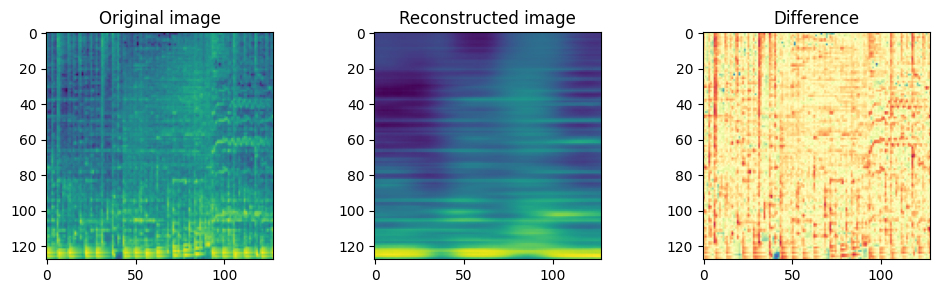

In [28]:
test_img = data_gen.__getitem__(1)[0]
prediction = autoencoder(test_img)

plot_reconstruction(test_img, prediction, 1)

Latent Space

In [77]:
latent_space=LatentSpace(autoencoder_path=model_path,
                       image_dir='/kaggle/input/datasets/hau100416/music-mel-spectrogram-dataset/',
                        track_df_path='/kaggle/input/datasets/amitanshjoshi/spotify-1million-tracks/spotify_data.csv',
                       latent_dims=256,sample_size=100,
                       output_size=(128,128),
                       num_tiles=64)

Found 100 files for Generator set


In [78]:
latent_space.build()

Getting predictions from autoencoder...
[============================================================>] 100 / 100

0.08 minutes elapsed
Building tracks dataframe
size of results 100
Track dataframe built. 0.07 minutes elapsed
Building artist distributions...
Artist distributions built. 0.0 minutes elapsed
Building genre distributions...
Genre distributions built. 0.0 minutes elapsed
Latent Space Built.


In [79]:
latent_space.save('/kaggle/working',save_full_results=True)

In [85]:
result=pd.read_csv('/kaggle/working/results.csv')
result.head()

,id,filename,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,...,latent_246,latent_247,latent_248,latent_249,latent_250,latent_251,latent_252,latent_253,latent_254,latent_255
0,06PSFW5hTOrPjho9Gxa7k6,test_3/comp_pngs/06PSFW5hTOrPjho9Gxa7k6.png,0.216084,-0.077487,-0.637903,-0.226478,-0.126457,-0.086278,0.265033,-0.069185,...,-0.006815,0.146373,0.521259,0.121956,-0.012660,-0.120034,0.153392,0.121795,-0.189271,-0.143497
1,0CXLj8pvwhTHTD2Jyp7trK,v8/comp_pngs/0CXLj8pvwhTHTD2Jyp7trK.png,-0.092077,-0.046011,-0.974312,-0.126982,-0.189221,0.144310,0.030288,0.028691,...,-0.525704,-0.125894,-0.037447,0.136073,-0.331691,-0.124985,-0.171634,-0.290856,-0.195619,-0.102611
2,08ZFnVp5nM5cXay9M8M5n3,test_4/comp_pngs/08ZFnVp5nM5cXay9M8M5n3.png,0.020117,0.109327,-0.443808,-0.245562,-0.033064,0.021264,-0.156125,0.047979,...,0.053930,0.526048,0.307490,0.173523,0.403630,-0.125517,0.070006,-0.268672,-0.094916,0.124342
3,0bOlznmPI9crQ8vF2YoQX7,v8/comp_pngs/0bOlznmPI9crQ8vF2YoQX7.png,0.179113,-0.265242,0.119203,-0.312157,-0.321604,-0.143461,0.380531,-0.294922,...,-0.170666,-0.239182,0.302498,0.086327,-0.405195,0.147132,0.220088,-0.140833,0.066394,0.036452
4,06derkiD6jeiRrrXbapIiA,test_3/comp_pngs/06derkiD6jeiRrrXbapIiA.png,0.145114,0.001447,-0.806138,-0.133878,0.080280,0.000219,0.297421,-0.220496,...,0.420938,0.110874,0.000536,0.248680,-0.140214,0.065813,0.183494,0.258407,-0.422721,0.104626
